# Movie Genre Classification — Ablation V2
## EfficientNetV2-M | HybridLoss | 384px | Head-Only Frozen

**Experiments:**
- E0: HeadHybrid baseline
  EfficientNetV2-M, 384px, 3-layer MLP, HybridLoss, augmentation
- E1: E0 + Co-occurrence violation loss (λ=0.1)
- E2: Per-class threshold search on E0 and E1 (inference only)

**Reuses from ablation_v1:**
- Same train/val/test split files
- Same augmentation pipeline (torchvision)
- Same evaluation metrics
- Same co-occurrence matrix computation

## 1. Installs & Imports

In [1]:
import sys
!{sys.executable} -m pip install -q iterative-stratification openpyxl timm scikit-learn
!{sys.executable} -m pip install -q pandas matplotlib seaborn pillow torch torchvision
print('Packages ready.')


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Packages ready.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, json, random, pickle, warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import f1_score, hamming_loss, roc_auc_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

sns.set_theme(style='whitegrid', font_scale=1.05)
SAVE_DPI = 150

device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DEVICE_TYPE = 'cuda' if device.type == 'cuda' else 'cpu'

print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print(f'PyTorch : {torch.__version__}')

Device  : cuda
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.6 GB
PyTorch : 2.10.0+cu126


## 2. Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Update BASE_PROJECT to match your machine
BASE_PROJECT = Path(r'D:\Skripsi\compviz')

BASE_DIR     = BASE_PROJECT / 'Datasets'
TRAIN_DIR    = BASE_DIR / 'images' / 'train'
TEST_DIR     = BASE_DIR / 'images' / 'test'
LABEL_FILE   = BASE_DIR / 'genre.xlsx'
SPLIT_DIR    = BASE_PROJECT / 'splits'       # reuse ablation_v1 splits
ROOT_OUT     = BASE_PROJECT / 'runs'
ABLATION_DIR = ROOT_OUT / 'ablation_v2'
PAPER_FIGS   = BASE_PROJECT / 'paper_figures_v2'

for d in [ABLATION_DIR, PAPER_FIGS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Genre columns ─────────────────────────────────────────────────────────────
GENRE_COLS  = ['action','adventure','animation','comedy','crime',
               'drama','family','fantasy','horror','musical',
               'mystery','romance','scifi','thriller']
NUM_CLASSES = len(GENRE_COLS)   # 14
RARE_GENRES = ['horror', 'musical']

# ── File ranges ───────────────────────────────────────────────────────────────
TRAIN_FILES = {f'{i}.jpg' for i in range(1, 251)}
TEST_FILES  = {f'{i}.jpg' for i in range(251, 301)}

# ── Model ─────────────────────────────────────────────────────────────────────
BACKBONE   = 'tf_efficientnetv2_m'
IMG_SIZE   = 384
BATCH_SIZE = 16          # smaller batch for 384px on limited VRAM

# ── Training ──────────────────────────────────────────────────────────────────
SEED          = 42
TOTAL_EPOCHS  = 70
PATIENCE      = 20
LR_HEAD       = 1e-3
WEIGHT_DECAY  = 1e-4

# ── Co-occurrence ─────────────────────────────────────────────────────────────
COOC_LAMBDA    = 0.1
COOC_THRESHOLD = 0.5

# ── DataLoader ────────────────────────────────────────────────────────────────
NUM_WORKERS        = 0
PIN_MEMORY         = True
PERSISTENT_WORKERS = False
PREFETCH_FACTOR    = None

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print('Config loaded.')
print(f'ABLATION_DIR : {ABLATION_DIR}')
print(f'SPLIT_DIR    : {SPLIT_DIR} (reused from ablation_v1)')
print(f'Backbone     : {BACKBONE}')
print(f'Image size   : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size   : {BATCH_SIZE}')

Config loaded.
ABLATION_DIR : D:\Skripsi\compviz\runs\ablation_v2
SPLIT_DIR    : D:\Skripsi\compviz\splits (reused from ablation_v1)
Backbone     : tf_efficientnetv2_m
Image size   : 384x384
Batch size   : 16


## 3. Experiment Registry

In [4]:
EXPERIMENT_CONFIGS = {
    'E0': {
        'name':        'HeadHybrid',
        'cooc_loss':   False,
        'description': 'EfficientNetV2-M + HybridLoss + Aug, '
                       'head-only frozen, no co-occurrence',
    },
    'E1': {
        'name':        'HeadHybrid_Cooc',
        'cooc_loss':   True,
        'description': 'E0 + co-occurrence violation loss (λ=0.1)',
    },
}

print('Experiment registry:')
for eid, cfg in EXPERIMENT_CONFIGS.items():
    print(f'  {eid} | {cfg["name"]:<25} | {cfg["description"]}')
print('\nE2: per-class threshold applied at inference to E0 and E1')

Experiment registry:
  E0 | HeadHybrid                | EfficientNetV2-M + HybridLoss + Aug, head-only frozen, no co-occurrence
  E1 | HeadHybrid_Cooc           | E0 + co-occurrence violation loss (λ=0.1)

E2: per-class threshold applied at inference to E0 and E1


## 4. Load Data & Splits

In [5]:
def load_splits() -> tuple:
    """
    Load pre-existing splits from ablation_v1 splits folder.
    Computes class weights and co-occurrence matrix from train split.
    """
    train_df = pd.read_csv(SPLIT_DIR / 'train_split.csv')
    val_df   = pd.read_csv(SPLIT_DIR / 'val_split.csv')
    test_df  = pd.read_csv(SPLIT_DIR / 'test_split.csv')

    for df in [train_df, val_df, test_df]:
        df['filename'] = df['filename'].astype(str)

    print(f'Train: {len(train_df)} | Val: {len(val_df)} | '
          f'Test: {len(test_df)}')

    # ── Class weights for weighted BCE (kept for reference) ───────────────
    pos_counts    = train_df[GENRE_COLS].sum(axis=0).values.astype(float)
    pos_counts    = np.clip(pos_counts, 1, None)
    neg_counts    = len(train_df) - pos_counts
    class_weights = torch.tensor(
        neg_counts / pos_counts, dtype=torch.float32)

    # ── Co-occurrence matrix P(col|row) from train originals ──────────────
    mat  = train_df[GENRE_COLS].T.dot(
               train_df[GENRE_COLS]).values.astype(float)
    diag = np.diag(mat).copy()
    diag[diag == 0] = 1.0
    cooc_matrix = mat / diag[:, None]
    np.fill_diagonal(cooc_matrix, 0.0)

    print('\nTop co-occurrence pairs (P > 0.8):')
    for i, g1 in enumerate(GENRE_COLS):
        for j, g2 in enumerate(GENRE_COLS):
            if i != j and cooc_matrix[i,j] > 0.8:
                print(f'  P({g2}|{g1}) = {cooc_matrix[i,j]:.3f}')

    return train_df, val_df, test_df, class_weights, cooc_matrix


train_df, val_df, test_df, class_weights, cooc_matrix = load_splits()

Train: 200 | Val: 50 | Test: 50

Top co-occurrence pairs (P > 0.8):
  P(action|adventure) = 0.820
  P(adventure|animation) = 0.947
  P(adventure|family) = 0.929
  P(animation|family) = 0.893
  P(adventure|fantasy) = 0.842
  P(comedy|musical) = 1.000
  P(action|scifi) = 0.914


## 5. Dataset & Transforms (384px)

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def letterbox_resize(img: Image.Image, size: int) -> Image.Image:
    """
    Pad to square with black bars, then resize.
    Same logic as ablation_v1 — only target size changes (384 vs 224).
    No squashing — portrait aspect ratio preserved.
    """
    w, h    = img.size
    max_dim = max(w, h)
    padded  = ImageOps.pad(img, (max_dim, max_dim), color=(0, 0, 0))
    return padded.resize((size, size), Image.BILINEAR)


def get_transforms(aug: bool):
    """
    Same augmentation strategy as ablation_v1.
    Letterbox happens in PosterDataset.__getitem__().
    aug=True  : train (flip, rotate, colour jitter)
    aug=False : val/test (no augmentation)
    """
    normalize = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    if aug:
        return T.Compose([
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=15),
            T.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.2, hue=0.05),
            T.ToTensor(), normalize,
        ])
    return T.Compose([T.ToTensor(), normalize])


class PosterDataset(Dataset):
    """
    Multilabel poster dataset.
    Letterboxes to IMG_SIZE (384px) — no squashing.
    Returns (image_tensor, label_tensor, filename).
    """
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(
                self.img_dir / row['filename']).convert('RGB')
            img = letterbox_resize(img, IMG_SIZE)
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0,0,0))
        if self.transform: img = self.transform(img)
        labels = torch.tensor(
            row[GENRE_COLS].values.astype(np.float32),
            dtype=torch.float32)
        return img, labels, row['filename']


def build_loaders(train_df, val_df):
    """Train and val DataLoaders. Augmentation always on for train."""
    train_ds = PosterDataset(
        train_df, TRAIN_DIR, transform=get_transforms(aug=True))
    val_ds   = PosterDataset(
        val_df, TRAIN_DIR, transform=get_transforms(aug=False))

    train_ld = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR)
    val_ld = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR)
    return train_ld, val_ld


def build_test_loader(test_df):
    """Test DataLoader — no augmentation, no shuffle."""
    return DataLoader(
        PosterDataset(test_df, TEST_DIR,
                      transform=get_transforms(aug=False)),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR)


print('Dataset and DataLoader classes ready.')
print(f'  Image size : {IMG_SIZE}x{IMG_SIZE} (letterbox, no squash)')
print(f'  Batch size : {BATCH_SIZE}')

Dataset and DataLoader classes ready.
  Image size : 384x384 (letterbox, no squash)
  Batch size : 16


## 6. Model — EfficientNetV2-M + 3-layer MLP Head

Backbone: EfficientNetV2-M pretrained on ImageNet-21k.
Head: Linear(feat_dim,512)→BN→ReLU→Dropout(0.4)
      →Linear(512,256)→BN→ReLU→Dropout(0.3)
      →Linear(256,14)
Freeze: entire backbone. Only head trainable (~792K params).
Same freeze philosophy as ablation_v1 — head-only.

In [7]:
class PosterModel(nn.Module):
    """EfficientNetV2-M backbone + 3-layer MLP classification head."""
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head     = head

    def forward(self, x):
        return self.head(self.backbone(x))


def create_model() -> nn.Module:
    """
    Build EfficientNetV2-M + 3-layer MLP head.
    Entire backbone frozen — head only trainable.
    """
    backbone = timm.create_model(
        BACKBONE, pretrained=True, num_classes=0)
    feat_dim = backbone.num_features

    # Freeze entire backbone
    for param in backbone.parameters():
        param.requires_grad = False

    # 3-layer MLP head
    head = nn.Sequential(
        nn.Linear(feat_dim, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES),
    )

    model     = PosterModel(backbone, head).to(device)
    frozen    = sum(p.numel() for p in model.parameters()
                    if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters()
                    if p.requires_grad)

    print(f'  Backbone  : {BACKBONE}')
    print(f'  Feat dim  : {feat_dim}')
    print(f'  Frozen    : {frozen:,} params (backbone)')
    print(f'  Trainable : {trainable:,} params (3-layer MLP head)')

    if trainable > 1_500_000:
        print(f'  WARNING: trainable {trainable:,} > 1.5M')
    else:
        print(f'  Freeze correct.')

    return model


print('Model factory ready.')

Model factory ready.


## 7. Loss Functions

HybridLoss = 0.5 × SigmoidF1Loss + 0.5 × FocalLoss
CoocLoss   = co-occurrence violation regulariser (unchanged from ablation_v1)
E1 total   = HybridLoss + CoocLoss

In [8]:
class SigmoidF1Loss(nn.Module):
    """
    Differentiable F1 loss via soft sigmoid approximation.
    Optimises F1 directly — aligns training objective with eval metric.
    Soft TP, FP, FN counts via sigmoid probabilities.
    Applied per-class then macro-averaged.
    """
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs  = torch.sigmoid(logits)
        tp     = (probs * targets).sum(dim=0)
        fp     = (probs * (1 - targets)).sum(dim=0)
        fn     = ((1 - probs) * targets).sum(dim=0)
        f1_per = (2 * tp) / (2 * tp + fp + fn + self.eps)
        return 1.0 - f1_per.mean()


class FocalLoss(nn.Module):
    """
    Focal Loss for multilabel classification.
    Down-weights easy examples, focuses on hard examples.
    gamma=2 is standard (Lin et al. 2017).
    Stabilises early training when SigmoidF1 alone is noisy.
    """
    def __init__(self, gamma=2.0, eps=1e-8):
        super().__init__()
        self.gamma = gamma
        self.eps   = eps

    def forward(self, logits, targets):
        probs    = torch.sigmoid(logits)
        bce_loss = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none')
        pt       = probs * targets + (1 - probs) * (1 - targets)
        return ((1 - pt) ** self.gamma * bce_loss).mean()


class HybridLoss(nn.Module):
    """
    Hybrid loss: 0.5 * SigmoidF1 + 0.5 * FocalLoss.
    SigmoidF1 directly optimises the evaluation metric.
    FocalLoss provides stable gradients in early training.
    Equal weighting by default.
    """
    def __init__(self, f1_weight=0.5, focal_weight=0.5, gamma=2.0):
        super().__init__()
        self.f1_loss    = SigmoidF1Loss()
        self.focal_loss = FocalLoss(gamma=gamma)
        self.f1_weight  = f1_weight
        self.focal_wt   = focal_weight

    def forward(self, logits, targets):
        return (self.f1_weight * self.f1_loss(logits, targets) +
                self.focal_wt  * self.focal_loss(logits, targets))


class CoocLoss(nn.Module):
    """
    Co-occurrence violation regulariser.
    Penalises predicting genre j while suppressing genre k
    when P(k|j) > threshold in training data.
    Additive term: L_total = L_hybrid + lambda * L_cooc
    """
    def __init__(self, cooc_matrix, lambda_=0.1, threshold=0.5):
        super().__init__()
        cooc_t = torch.tensor(cooc_matrix, dtype=torch.float32)
        self.register_buffer('strong_pairs',
                              (cooc_t > threshold).float())
        self.lambda_ = lambda_
        self.eps     = 1e-8

    def forward(self, logits, targets):
        probs14   = torch.sigmoid(logits)
        prob_i    = probs14.unsqueeze(2)
        prob_j    = probs14.unsqueeze(1)
        violation = (prob_i - prob_j).clamp(min=0)
        penalty   = (violation *
                     self.strong_pairs.unsqueeze(0)).sum()
        return self.lambda_ * penalty / (logits.size(0) + self.eps)


def build_criterion(cfg, cooc_matrix):
    """Build loss from experiment config."""
    hybrid = HybridLoss(f1_weight=0.5, focal_weight=0.5, gamma=2.0)
    if cfg['cooc_loss']:
        cooc_fn = CoocLoss(
            cooc_matrix, lambda_=COOC_LAMBDA,
            threshold=COOC_THRESHOLD).to(device)
        def criterion(logits, targets):
            return hybrid(logits, targets) + \
                   cooc_fn(logits, targets)
        return criterion
    return hybrid


print('Loss functions ready.')
print('  SigmoidF1Loss : direct F1 optimisation')
print('  FocalLoss     : hard example mining')
print('  HybridLoss    : 0.5xSigmoidF1 + 0.5xFocalLoss')
print('  CoocLoss      : co-occurrence violation regulariser')

Loss functions ready.
  SigmoidF1Loss : direct F1 optimisation
  FocalLoss     : hard example mining
  HybridLoss    : 0.5xSigmoidF1 + 0.5xFocalLoss
  CoocLoss      : co-occurrence violation regulariser


## 8. Metrics

In [9]:
def jaccard_pla(y_true, y_pred):
    scores = []
    for t, p in zip(y_true, y_pred):
        tp = ((t==1)&(p==1)).sum()
        fp = ((t==0)&(p==1)).sum()
        fn = ((t==1)&(p==0)).sum()
        d  = tp + fp + fn
        scores.append(float(tp/d) if d > 0 else 1.0)
    return float(np.mean(scores)) if scores else 0.0


def exact_match(y_true, y_pred):
    return float(np.all(y_true == y_pred, axis=1).mean())


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred  = (y_prob >= threshold).astype(int)
    f1_mac  = f1_score(y_true, y_pred, average='macro',
                        zero_division=0)
    h_loss  = hamming_loss(y_true, y_pred)
    f1_per  = f1_score(y_true, y_pred, average=None,
                        zero_division=0)
    jpla    = jaccard_pla(y_true, y_pred)
    emr     = exact_match(y_true, y_pred)

    auc_per = []
    for i in range(NUM_CLASSES):
        if len(np.unique(y_true[:,i])) > 1:
            auc_per.append(roc_auc_score(y_true[:,i], y_prob[:,i]))
        else:
            auc_per.append(float('nan'))

    rare_idx  = [GENRE_COLS.index(g) for g in RARE_GENRES]
    rare_true = np.clip(y_true[:,rare_idx].sum(axis=1), 0, 1)
    rare_pred = np.clip(y_pred[:,rare_idx].sum(axis=1), 0, 1)
    rare_f1   = f1_score(rare_true, rare_pred, zero_division=0)

    return {
        'f1_macro':     round(float(f1_mac), 4),
        'hamming_loss': round(float(h_loss),  4),
        'hamming_acc':  round(float(1-h_loss),4),
        'jaccard_pla':  round(float(jpla),    4),
        'exact_match':  round(float(emr),     4),
        'auc_macro':    round(float(np.nanmean(auc_per)), 4),
        'rare_f1':      round(float(rare_f1), 4),
        'f1_per_class': {g: round(float(v),4)
                         for g,v in zip(GENRE_COLS, f1_per)},
    }


def find_best_thresholds(y_true, y_prob,
                          grid=np.arange(0.05, 0.95, 0.025)):
    thresholds = np.full(NUM_CLASSES, 0.5)
    for i in range(NUM_CLASSES):
        best_f1 = -1.0
        for t in grid:
            f1 = f1_score(y_true[:,i],
                          (y_prob[:,i]>=t).astype(int),
                          zero_division=0)
            if f1 > best_f1:
                best_f1, thresholds[i] = f1, t
        if best_f1 < 0.05:
            thresholds[i] = 0.05
    return thresholds


print('Metrics ready.')
print('  F1-macro    : primary')
print('  Hamming Acc : label-level accuracy')
print('  Jaccard PLA : penalises false positives')
print('  Exact Match : strictest — all 14 labels must match')

Metrics ready.
  F1-macro    : primary
  Hamming Acc : label-level accuracy
  Jaccard PLA : penalises false positives
  Exact Match : strictest — all 14 labels must match


## 9. Training Engine

In [10]:
@torch.no_grad()
def evaluate(model, loader):
    """Inference on loader. Returns (y_true, y_prob)."""
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        with autocast(AMP_DEVICE_TYPE):
            logits = model(imgs)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.numpy())
    return (np.concatenate(all_labels).round().astype(int),
            np.concatenate(all_probs))


def _plot_history(history, exp_id, name, exp_dir):
    """4-panel training history. No title on figure — clean for paper."""
    epochs  = history['epoch']
    best_ep = epochs[history['val_f1'].index(max(history['val_f1']))]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'{exp_id} — {name}',
                 fontsize=13, fontweight='bold')

    plots = [
        (axes[0],'train_loss','Train Loss',   'Loss','min','#2196F3'),
        (axes[1],'val_loss',  'Val Loss',     'Loss','min','#FF5722'),
        (axes[2],'val_f1',    'Val F1-macro','F1',  'max','#4CAF50'),
        (axes[3],'val_hamming','Val Hamming', 'Ham', 'min','#F44336'),
    ]
    for ax, key, title, ylabel, mode, color in plots:
        vals = history[key]
        ax.plot(epochs, vals, color=color, linewidth=2)
        bv = (max if mode=='max' else min)(vals)
        be = epochs[vals.index(bv)]
        ax.scatter([be], [bv], color='black', zorder=5, s=50)
        ax.annotate(f'{bv:.4f}', xy=(be,bv),
                    xytext=(4,4), textcoords='offset points',
                    fontsize=8)
        ax.axvline(best_ep, color='green', linestyle='--',
                   linewidth=1.0,
                   label=f'Best F1@E{best_ep}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(exp_dir / 'training_history.png',
                dpi=SAVE_DPI, bbox_inches='tight')
    plt.show(); plt.close()


def train_experiment(exp_id, cfg, train_df, val_df,
                      cooc_matrix):
    """
    Full training pipeline.
    Re-run safe: skips if final_model.pt exists.
    Resume safe: resumes from checkpoint.pt if interrupted.
    """
    exp_dir    = ABLATION_DIR / f'{exp_id}_{cfg["name"]}'
    exp_dir.mkdir(parents=True, exist_ok=True)
    model_path = exp_dir / 'final_model.pt'
    ckpt_path  = exp_dir / 'checkpoint.pt'

    if model_path.exists():
        print(f'[SKIP] {exp_id} — final_model.pt exists.')
        with open(exp_dir / 'val_results.json') as f:
            return json.load(f)

    print(f'\n{"="*60}')
    print(f'  {exp_id} | {cfg["name"]}')
    print(f'  {cfg["description"]}')
    print(f'  cooc_loss={cfg["cooc_loss"]}')
    print(f'{"="*60}')

    with open(exp_dir / 'experiment_config.json', 'w') as f:
        json.dump({**cfg, 'exp_id': exp_id,
                   'backbone': BACKBONE,
                   'img_size': IMG_SIZE,
                   'batch_size': BATCH_SIZE,
                   'timestamp': datetime.now().isoformat()},
                  f, indent=2)

    train_ld, val_ld = build_loaders(train_df, val_df)
    model     = create_model()
    criterion = build_criterion(cfg, cooc_matrix)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=TOTAL_EPOCHS, eta_min=1e-7)
    scaler    = GradScaler(AMP_DEVICE_TYPE)

    history = {
        'epoch':[], 'train_loss':[], 'val_loss':[],
        'val_f1':[], 'val_hamming':[]}

    best_val_f1      = -1.0
    best_model_state = None
    patience_ctr     = 0
    start_epoch      = 1

    # ── Resume ────────────────────────────────────────────────────
    if ckpt_path.exists():
        print('Resuming from checkpoint...')
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        start_epoch  = ckpt['epoch'] + 1
        best_val_f1  = ckpt['best_val_f1']
        patience_ctr = ckpt['patience_ctr']
        history      = ckpt['history']
        print(f'  Resumed epoch {start_epoch} | '
              f'best F1: {best_val_f1:.4f}')

    # ── Training loop ─────────────────────────────────────────────
    for epoch in range(start_epoch, TOTAL_EPOCHS + 1):
        model.train()
        total_train = 0.0
        for imgs, labels, _ in train_ld:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            with autocast(AMP_DEVICE_TYPE):
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
            total_train += loss.item()
        train_loss = total_train / len(train_ld)
        scheduler.step()

        # Validate
        y_true, y_prob = evaluate(model, val_ld)
        m = compute_metrics(y_true, y_prob)

        # Val loss
        model.eval()
        total_val = 0.0
        with torch.no_grad():
            for imgs, labels, _ in val_ld:
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with autocast(AMP_DEVICE_TYPE):
                    total_val += criterion(
                        model(imgs), labels).item()
        val_loss = total_val / len(val_ld)

        history['epoch'].append(epoch)
        history['train_loss'].append(round(train_loss, 4))
        history['val_loss'].append(round(val_loss, 4))
        history['val_f1'].append(m['f1_macro'])
        history['val_hamming'].append(m['hamming_loss'])

        improved = m['f1_macro'] > best_val_f1
        if improved:
            best_val_f1      = m['f1_macro']
            best_model_state = {
                k: v.cpu().clone()
                for k,v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        print(f'  Ep {epoch:3d}/{TOTAL_EPOCHS} | '
              f'TL:{train_loss:.4f} VL:{val_loss:.4f} | '
              f'VF1:{m["f1_macro"]:.4f} '
              f'Ham:{m["hamming_loss"]:.4f} | '
              f'{"✅" if improved else f"pat {patience_ctr}/{PATIENCE}"}')

        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'scaler_state':    scaler.state_dict(),
            'best_val_f1':     best_val_f1,
            'patience_ctr':    patience_ctr,
            'history':         history,
        }, ckpt_path)

        if patience_ctr >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}.')
            break

    # ── Load best model ───────────────────────────────────────────
    model.load_state_dict(
        {k: v.to(device) for k,v in best_model_state.items()})
    print(f'\n  Best val F1: {best_val_f1:.4f}')

    with open(exp_dir / 'history.pkl', 'wb') as f:
        pickle.dump(history, f)
    _plot_history(history, exp_id, cfg['name'], exp_dir)

    # ── Val metrics + thresholds ──────────────────────────────────
    y_true, y_prob  = evaluate(model, val_ld)
    val_results     = compute_metrics(y_true, y_prob)
    val_results['exp_id']     = exp_id
    val_results['name']       = cfg['name']
    val_results['best_epoch'] = history['val_f1'].index(
        best_val_f1) + 1
    val_results['config']     = {
        **cfg, 'backbone': BACKBONE,
        'img_size': IMG_SIZE, 'batch_size': BATCH_SIZE}

    with open(exp_dir / 'val_results.json', 'w') as f:
        json.dump(val_results, f, indent=2)

    thresholds = find_best_thresholds(y_true, y_prob)
    torch.save({
        'state_dict': model.state_dict(),
        'thresholds': thresholds.tolist(),
        'config':     val_results['config'],
        'timestamp':  datetime.now().isoformat(),
    }, model_path)

    if ckpt_path.exists(): ckpt_path.unlink()
    del model; torch.cuda.empty_cache()
    print(f'  Saved to {exp_dir}')
    return val_results


print('Training engine ready.')

Training engine ready.


## 10. Run E0 and E1

Running E0 — HeadHybrid baseline...

  E0 | HeadHybrid
  EfficientNetV2-M + HybridLoss + Aug, head-only frozen, no co-occurrence
  cooc_loss=False
  Backbone  : tf_efficientnetv2_m
  Feat dim  : 1280
  Frozen    : 52,858,356 params (backbone)
  Trainable : 792,334 params (3-layer MLP head)
  Freeze correct.
  Ep   1/70 | TL:0.4191 VL:0.4112 | VF1:0.4592 Ham:0.2514 | ✅
  Ep   2/70 | TL:0.3634 VL:0.3925 | VF1:0.4493 Ham:0.2214 | pat 1/20
  Ep   3/70 | TL:0.3428 VL:0.3878 | VF1:0.4813 Ham:0.2243 | ✅
  Ep   4/70 | TL:0.3219 VL:0.3863 | VF1:0.4984 Ham:0.2243 | ✅
  Ep   5/70 | TL:0.2984 VL:0.3790 | VF1:0.5188 Ham:0.2143 | ✅
  Ep   6/70 | TL:0.2895 VL:0.3746 | VF1:0.5117 Ham:0.2057 | pat 1/20
  Ep   7/70 | TL:0.2660 VL:0.3727 | VF1:0.5126 Ham:0.1900 | pat 2/20
  Ep   8/70 | TL:0.2403 VL:0.3800 | VF1:0.4607 Ham:0.2157 | pat 3/20
  Ep   9/70 | TL:0.2372 VL:0.3839 | VF1:0.4614 Ham:0.2057 | pat 4/20
  Ep  10/70 | TL:0.2221 VL:0.3780 | VF1:0.4678 Ham:0.2029 | pat 5/20
  Ep  11/70 | TL:0.2208 VL:0.

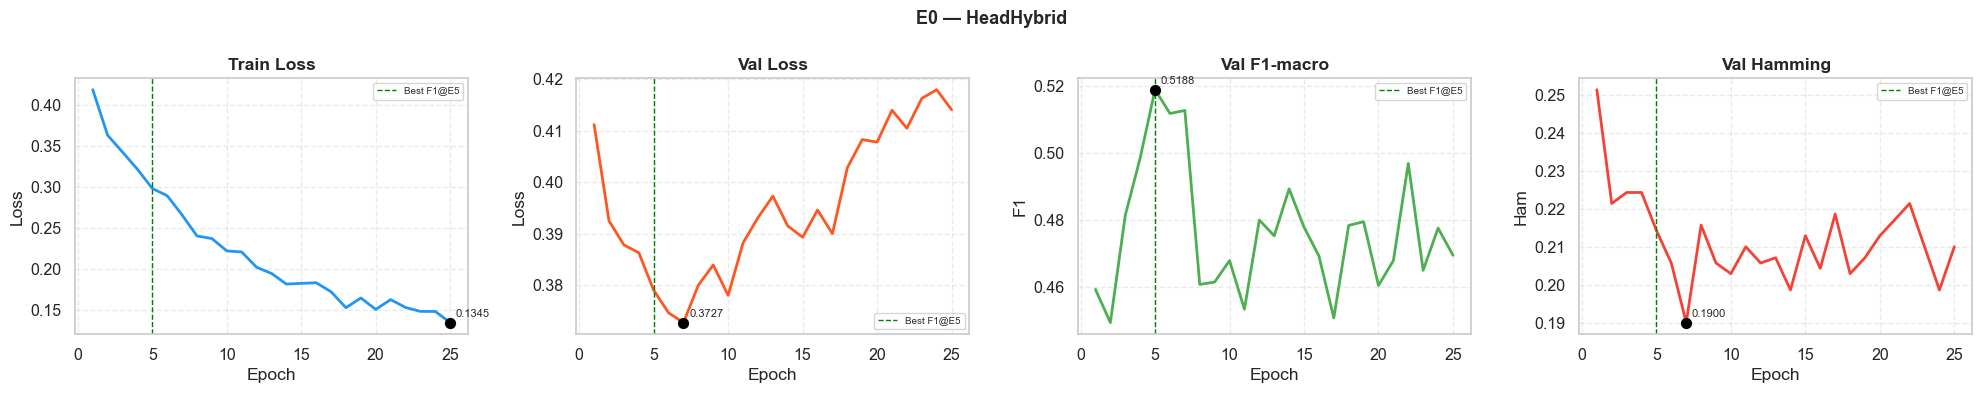

  Saved to D:\Skripsi\compviz\runs\ablation_v2\E0_HeadHybrid

Running E1 — HeadHybrid + CoocLoss...

  E1 | HeadHybrid_Cooc
  E0 + co-occurrence violation loss (λ=0.1)
  cooc_loss=True


  Backbone  : tf_efficientnetv2_m
  Feat dim  : 1280
  Frozen    : 52,858,356 params (backbone)
  Trainable : 792,334 params (3-layer MLP head)
  Freeze correct.
  Ep   1/70 | TL:0.4957 VL:0.4311 | VF1:0.3275 Ham:0.2986 | ✅
  Ep   2/70 | TL:0.4355 VL:0.4188 | VF1:0.3975 Ham:0.2443 | ✅
  Ep   3/70 | TL:0.4079 VL:0.4198 | VF1:0.4428 Ham:0.2300 | ✅
  Ep   4/70 | TL:0.3966 VL:0.4208 | VF1:0.4402 Ham:0.2600 | pat 1/20
  Ep   5/70 | TL:0.3752 VL:0.4123 | VF1:0.4613 Ham:0.2400 | ✅
  Ep   6/70 | TL:0.3621 VL:0.4017 | VF1:0.4833 Ham:0.2271 | ✅
  Ep   7/70 | TL:0.3496 VL:0.4016 | VF1:0.4797 Ham:0.2171 | pat 1/20
  Ep   8/70 | TL:0.3388 VL:0.4027 | VF1:0.4829 Ham:0.2243 | pat 2/20
  Ep   9/70 | TL:0.3382 VL:0.3991 | VF1:0.4805 Ham:0.2300 | pat 3/20
  Ep  10/70 | TL:0.3210 VL:0.3972 | VF1:0.4597 Ham:0.2257 | pat 4/20
  Ep  11/70 | TL:0.3165 VL:0.3982 | VF1:0.4739 Ham:0.2286 | pat 5/20
  Ep  12/70 | TL:0.3074 VL:0.3958 | VF1:0.4750 Ham:0.2329 | pat 6/20
  Ep  13/70 | TL:0.3068 VL:0.4014 | VF1:0.527

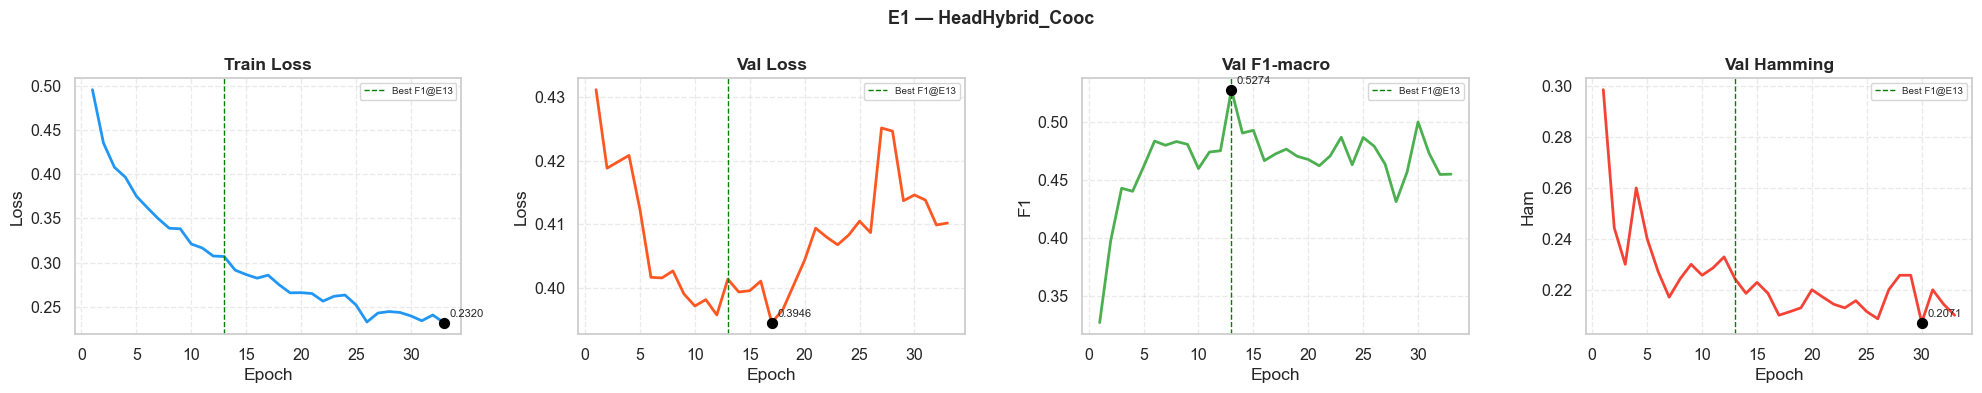

  Saved to D:\Skripsi\compviz\runs\ablation_v2\E1_HeadHybrid_Cooc

  VAL LEADERBOARD
  Exp    Name                        Val F1
  -----------------------------------------
  E0     HeadHybrid                  0.5188
  E1     HeadHybrid_Cooc             0.5274 ◀

E0 and E1 training complete.


In [11]:
all_results = {}

# ── E0 — HeadHybrid baseline ──────────────────────────────────────────────────
print('Running E0 — HeadHybrid baseline...')
all_results['E0'] = train_experiment(
    'E0', EXPERIMENT_CONFIGS['E0'],
    train_df, val_df, cooc_matrix)

# ── E1 — HeadHybrid + CoocLoss ────────────────────────────────────────────────
print('\nRunning E1 — HeadHybrid + CoocLoss...')
all_results['E1'] = train_experiment(
    'E1', EXPERIMENT_CONFIGS['E1'],
    train_df, val_df, cooc_matrix)

# ── Leaderboard ───────────────────────────────────────────────────────────────
print(f'\n{"="*45}')
print('  VAL LEADERBOARD')
print(f'{"="*45}')
print(f'  {"Exp":<6} {"Name":<25} {"Val F1":>8}')
print(f'  {"-"*41}')
for eid in ['E0','E1']:
    r   = all_results[eid]
    mrk = ' ◀' if r['f1_macro'] == max(
        v['f1_macro'] for v in all_results.values()) else ''
    print(f'  {eid:<6} {r["name"]:<25} '
          f'{r["f1_macro"]:>8.4f}{mrk}')
print(f'{"="*45}')
print('\nE0 and E1 training complete.')

## 11. Test Set Evaluation — E0, E1, E2

E2 = per-class threshold applied to E0 and E1.
Test set touched here for the FIRST TIME.

In [12]:
def evaluate_on_test(all_results, test_df, cooc_matrix):
    """
    Load each model, run inference on test set.
    Each evaluated with fixed 0.5 and per-class threshold (E2).
    """
    test_loader  = build_test_loader(test_df)
    test_results = {}

    for exp_id, val_res in all_results.items():
        cfg         = val_res['config']
        exp_dir     = ABLATION_DIR / f'{exp_id}_{cfg["name"]}'
        model_path  = exp_dir / 'final_model.pt'
        result_path = exp_dir / 'test_results.json'

        if result_path.exists():
            print(f'[SKIP] {exp_id} test results exist.')
            with open(result_path) as f:
                test_results[exp_id] = json.load(f)
            continue

        print(f'\nEvaluating {exp_id} on test set...')
        ckpt  = torch.load(model_path, map_location=device)
        model = create_model()
        model.load_state_dict(ckpt['state_dict'])
        model.eval()

        y_true, y_prob = evaluate(model, test_loader)

        # Fixed 0.5
        m_fixed = compute_metrics(y_true, y_prob, threshold=0.5)

        # Per-class threshold (E2)
        thresholds = np.array(ckpt['thresholds'])
        y_pred_pc  = (y_prob >= thresholds[None,:]).astype(int)
        f1_pc   = f1_score(y_true, y_pred_pc,
                            average='macro', zero_division=0)
        h_pc    = hamming_loss(y_true, y_pred_pc)
        jac_pc  = jaccard_pla(y_true, y_pred_pc)
        emr_pc  = exact_match(y_true, y_pred_pc)
        f1p_pc  = f1_score(y_true, y_pred_pc,
                            average=None, zero_division=0)
        rare_idx = [GENRE_COLS.index(g) for g in RARE_GENRES]
        rare_t   = np.clip(y_true[:,rare_idx].sum(axis=1), 0, 1)
        rare_p   = np.clip(y_pred_pc[:,rare_idx].sum(axis=1), 0, 1)
        rare_f1  = float(f1_score(rare_t, rare_p, zero_division=0))

        result = {
            'exp_id': exp_id,
            'name':   cfg['name'],
            'config': cfg,
            'fixed_0_5': m_fixed,
            'per_class_thresh': {
                'f1_macro':    round(float(f1_pc),  4),
                'hamming_loss':round(float(h_pc),   4),
                'hamming_acc': round(float(1-h_pc), 4),
                'jaccard_pla': round(float(jac_pc), 4),
                'exact_match': round(float(emr_pc), 4),
                'auc_macro':   m_fixed['auc_macro'],
                'rare_f1':     round(rare_f1, 4),
                'f1_per_class':{g: round(float(v),4)
                                for g,v in zip(GENRE_COLS,f1p_pc)},
            },
            'thresholds': {g: round(float(t),4)
                           for g,t in zip(GENRE_COLS,thresholds)},
            'timestamp': datetime.now().isoformat(),
        }

        with open(result_path, 'w') as f:
            json.dump(result, f, indent=2)

        print(f'  Fixed 0.5 → '
              f'F1:{m_fixed["f1_macro"]:.4f} '
              f'Ham:{m_fixed["hamming_loss"]:.4f} '
              f'HamAcc:{m_fixed["hamming_acc"]:.4f} '
              f'Jac:{m_fixed["jaccard_pla"]:.4f} '
              f'EMR:{m_fixed["exact_match"]:.4f}')
        print(f'  PerClass  → '
              f'F1:{f1_pc:.4f} '
              f'Ham:{h_pc:.4f} '
              f'HamAcc:{1-h_pc:.4f} '
              f'Jac:{jac_pc:.4f} '
              f'EMR:{emr_pc:.4f}')

        test_results[exp_id] = result
        del model; torch.cuda.empty_cache()

    return test_results


test_results = evaluate_on_test(all_results, test_df, cooc_matrix)
print('\nTest evaluation complete.')


Evaluating E0 on test set...
  Backbone  : tf_efficientnetv2_m
  Feat dim  : 1280
  Frozen    : 52,858,356 params (backbone)
  Trainable : 792,334 params (3-layer MLP head)
  Freeze correct.
  Fixed 0.5 → F1:0.4657 Ham:0.2171 HamAcc:0.7829 Jac:0.4975 EMR:0.0400
  PerClass  → F1:0.4765 Ham:0.2814 HamAcc:0.7186 Jac:0.4548 EMR:0.0400

Evaluating E1 on test set...
  Backbone  : tf_efficientnetv2_m
  Feat dim  : 1280
  Frozen    : 52,858,356 params (backbone)
  Trainable : 792,334 params (3-layer MLP head)
  Freeze correct.
  Fixed 0.5 → F1:0.4114 Ham:0.2500 HamAcc:0.7500 Jac:0.4651 EMR:0.0400
  PerClass  → F1:0.4431 Ham:0.2700 HamAcc:0.7300 Jac:0.4626 EMR:0.0800

Test evaluation complete.


## 12. Comparison Table

In [13]:
def print_comparison(test_results):
    eids = sorted(test_results.keys())

    for thresh_key, thresh_label in [
        ('fixed_0_5',       'Fixed threshold 0.5'),
        ('per_class_thresh','Per-class threshold (E2)'),
    ]:
        f1_vals = [test_results[e][thresh_key]['f1_macro']
                   for e in eids]
        print(f'\n{"="*72}')
        print(f'  TEST RESULTS — {thresh_label}')
        print(f'{"="*72}')
        print(f'  {"Exp":<6} {"Name":<25} '
              f'{"F1":>7} {"HamLoss":>9} '
              f'{"HamAcc":>8} {"Jaccard":>9} {"EMR":>7}')
        print(f'  {"-"*69}')
        for i, e in enumerate(eids):
            r   = test_results[e][thresh_key]
            mrk = ' ◀' if r['f1_macro'] == max(f1_vals) else ''
            print(f'  {e:<6} '
                  f'{test_results[e]["name"]:<25} '
                  f'{r["f1_macro"]:>7.4f}{mrk} '
                  f'{r["hamming_loss"]:>9.4f} '
                  f'{r["hamming_acc"]:>8.4f} '
                  f'{r["jaccard_pla"]:>9.4f} '
                  f'{r["exact_match"]:>7.4f}')
        print(f'{"="*72}')


print_comparison(test_results)


  TEST RESULTS — Fixed threshold 0.5
  Exp    Name                           F1   HamLoss   HamAcc   Jaccard     EMR
  ---------------------------------------------------------------------
  E0     HeadHybrid                 0.4657 ◀    0.2171   0.7829    0.4975  0.0400
  E1     HeadHybrid_Cooc            0.4114    0.2500   0.7500    0.4651  0.0400

  TEST RESULTS — Per-class threshold (E2)
  Exp    Name                           F1   HamLoss   HamAcc   Jaccard     EMR
  ---------------------------------------------------------------------
  E0     HeadHybrid                 0.4765 ◀    0.2814   0.7186    0.4548  0.0400
  E1     HeadHybrid_Cooc            0.4431    0.2700   0.7300    0.4626  0.0800


## 13. Comparison Plots

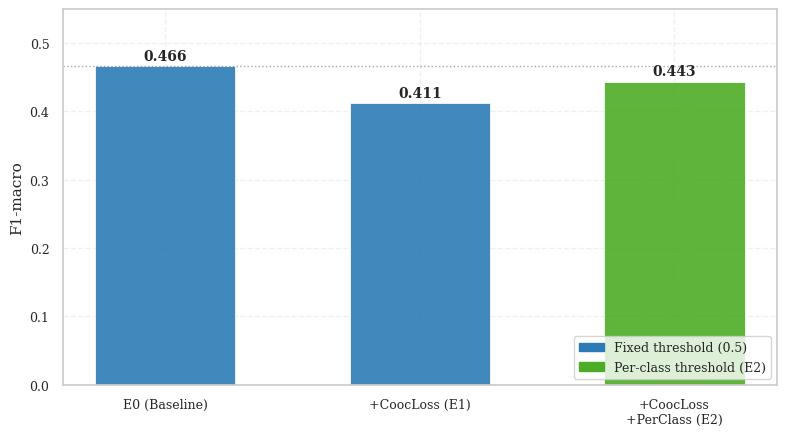

Saved: fig7_f1_bar.png


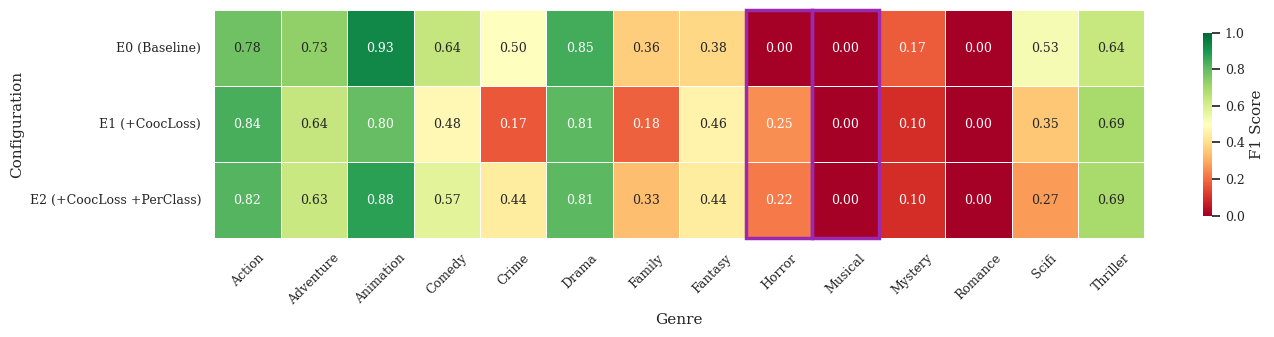

Saved: fig8_perclass_heatmap.png


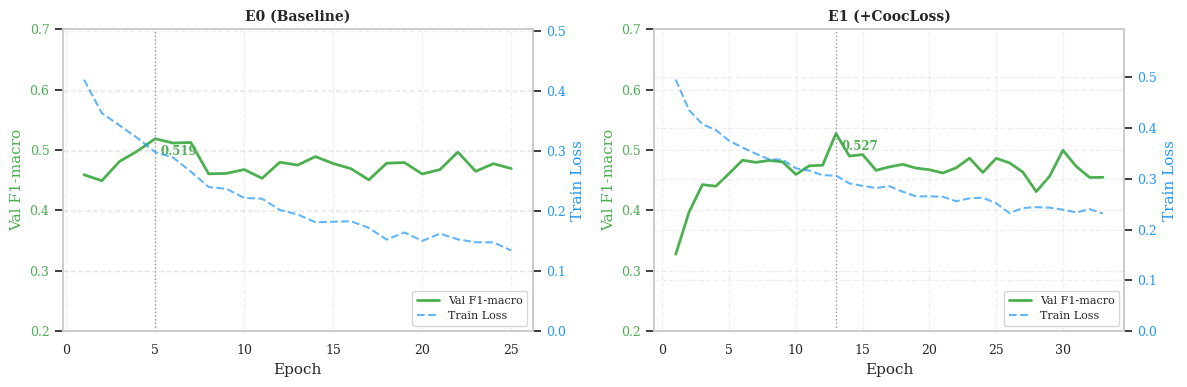

Saved: fig9_learning_curves.png

All figures saved to D:\Skripsi\compviz\paper_figures_v2


In [14]:
def plot_all(test_results, all_results, paper_dir):
    """
    Generate three clean paper figures:
    Fig 7 — F1-macro bar chart (E0, E1, E1+PerClass)
    Fig 8 — Per-class F1 heatmap (3 rows)
    Fig 9 — Learning curves (E0 and E1 side by side)
    No titles on figures — captions handled in LaTeX.
    """
    plt.rcParams.update({
        'font.family': 'serif', 'font.size': 11,
        'axes.labelsize': 11, 'xtick.labelsize': 9,
        'ytick.labelsize': 9, 'axes.grid': True,
        'grid.alpha': 0.3, 'grid.linestyle': '--',
        'savefig.dpi': 300, 'savefig.bbox': 'tight',
        'savefig.facecolor': 'white',
    })

    COLOR_FIXED = '#2C7BB6'
    COLOR_PC    = '#4DAC26'
    RARE        = set(RARE_GENRES)

    # ── Fig 7 — F1 bar chart ──────────────────────────────────────
    configs = [
        ('E0 (Baseline)', test_results['E0']['fixed_0_5']['f1_macro'],
         COLOR_FIXED),
        ('+CoocLoss (E1)', test_results['E1']['fixed_0_5']['f1_macro'],
         COLOR_FIXED),
        ('+CoocLoss\n+PerClass (E2)',
         test_results['E1']['per_class_thresh']['f1_macro'],
         COLOR_PC),
    ]
    labels, vals, colors = zip(*configs)
    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(x, vals, width=0.55, color=colors,
                  edgecolor='white', linewidth=0.6, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.axhline(vals[0], color='gray', linewidth=1.0,
               linestyle=':', alpha=0.7,
               label=f'Baseline = {vals[0]:.3f}')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0, max(vals) * 1.18)
    handles = [
        mpatches.Patch(color=COLOR_FIXED, label='Fixed threshold (0.5)'),
        mpatches.Patch(color=COLOR_PC,    label='Per-class threshold (E2)'),
    ]
    ax.legend(handles=handles, fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig(paper_dir / 'fig7_f1_bar.png')
    plt.show(); plt.close()
    print('Saved: fig7_f1_bar.png')

    # ── Fig 8 — Per-class heatmap ─────────────────────────────────
    row_labels = [
        'E0 (Baseline)',
        'E1 (+CoocLoss)',
        'E2 (+CoocLoss +PerClass)',
    ]
    f1_matrix = np.array([
        [test_results['E0']['fixed_0_5']['f1_per_class'][g]
         for g in GENRE_COLS],
        [test_results['E1']['fixed_0_5']['f1_per_class'][g]
         for g in GENRE_COLS],
        [test_results['E1']['per_class_thresh']['f1_per_class'][g]
         for g in GENRE_COLS],
    ])

    fig, ax = plt.subplots(figsize=(14, 3.5))
    sns.heatmap(f1_matrix, annot=True, fmt='.2f',
                cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=[g.capitalize() for g in GENRE_COLS],
                yticklabels=row_labels,
                linewidths=0.4, linecolor='white', ax=ax,
                cbar_kws={'label':'F1 Score','shrink':0.8},
                annot_kws={'size': 9})
    rare_idx = [GENRE_COLS.index(g) for g in RARE_GENRES]
    for idx in rare_idx:
        ax.add_patch(plt.Rectangle(
            (idx, 0), 1, 3,
            fill=False, edgecolor='#9C27B0',
            lw=2.5, clip_on=False))
    ax.set_xlabel('Genre')
    ax.set_ylabel('Configuration')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(paper_dir / 'fig8_perclass_heatmap.png')
    plt.show(); plt.close()
    print('Saved: fig8_perclass_heatmap.png')

    # ── Fig 9 — Learning curves ───────────────────────────────────
    exp_list = [
        ('E0_HeadHybrid',      'E0 (Baseline)'),
        ('E1_HeadHybrid_Cooc', 'E1 (+CoocLoss)'),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    for ax, (folder, label) in zip(axes, exp_list):
        hist_path = ABLATION_DIR / folder / 'history.pkl'
        with open(hist_path, 'rb') as f:
            h = pickle.load(f)
        epochs     = h['epoch']
        val_f1     = h['val_f1']
        train_loss = h['train_loss']
        best_f1    = max(val_f1)
        best_ep    = epochs[val_f1.index(best_f1)]
        ax2 = ax.twinx()
        l1, = ax.plot(epochs, val_f1, color='#4CAF50',
                      linewidth=2, label='Val F1-macro')
        l2, = ax2.plot(epochs, train_loss, color='#2196F3',
                       linewidth=1.5, linestyle='--',
                       alpha=0.7, label='Train Loss')
        ax.axvline(best_ep, color='gray', linewidth=1.0,
                   linestyle=':', alpha=0.8)
        ax.annotate(f'{best_f1:.3f}',
                    xy=(best_ep, best_f1),
                    xytext=(4,-12),
                    textcoords='offset points',
                    fontsize=8.5, color='#4CAF50',
                    fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylim(0.20, 0.70)
        ax2.set_ylim(0, max(train_loss) * 1.2)
        ax.set_ylabel('Val F1-macro', color='#4CAF50')
        ax2.set_ylabel('Train Loss',  color='#2196F3')
        ax.tick_params(axis='y', labelcolor='#4CAF50')
        ax2.tick_params(axis='y', labelcolor='#2196F3')
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(handles=[l1,l2], fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(paper_dir / 'fig9_learning_curves.png')
    plt.show(); plt.close()
    print('Saved: fig9_learning_curves.png')


plot_all(test_results, all_results, PAPER_FIGS)
print(f'\nAll figures saved to {PAPER_FIGS}')

## 14. Save Full Summary

In [15]:
comp_dir = ABLATION_DIR / 'comparison'
comp_dir.mkdir(exist_ok=True)

with open(comp_dir / 'results_summary.json', 'w') as f:
    json.dump({
        'experiments':   test_results,
        'best_fixed':    max(test_results,
            key=lambda e:
            test_results[e]['fixed_0_5']['f1_macro']),
        'best_perclass': max(test_results,
            key=lambda e:
            test_results[e]['per_class_thresh']['f1_macro']),
        'timestamp':     datetime.now().isoformat(),
    }, f, indent=2)

print(f'Summary saved to {comp_dir / "results_summary.json"}')
print('\nDone. Ablation v2 complete.')
print('\nFinal results:')
for e in ['E0','E1']:
    r = test_results[e]['fixed_0_5']
    print(f'  {e} {test_results[e]["name"]:<25} '
          f'F1:{r["f1_macro"]:.4f} '
          f'HamAcc:{r["hamming_acc"]:.4f} '
          f'Jac:{r["jaccard_pla"]:.4f} '
          f'EMR:{r["exact_match"]:.4f}')

Summary saved to D:\Skripsi\compviz\runs\ablation_v2\comparison\results_summary.json

Done. Ablation v2 complete.

Final results:
  E0 HeadHybrid                F1:0.4657 HamAcc:0.7829 Jac:0.4975 EMR:0.0400
  E1 HeadHybrid_Cooc           F1:0.4114 HamAcc:0.7500 Jac:0.4651 EMR:0.0400
